# Reto 2.- Analisis de Datos sobre Criminalidad
- *Mision*.- Analizar los datos y hacer conclusiones en la distribucion y naturaleza del crimen en la Ciudad de Montreal. En el analisis, debe incluir mapas que visualice la localizacion de los diferentes incidentes existentes y la relacion con los distritos policiales. Tambien se debe de responder las siguientes preguntas:

    * Cuales son los primeros 3 crimenes relevantes u ofensas cometidas en la Ciudad de Montreal?
    * A que horario del dia suceden la mayoria de incidentes?
    * Cual de los 5 departamentos de policia (PDQ) tienen la mayor denuncia de delitos?
    * Cuales son los primeros 3 PDQs que tienen la menor denuncia de delitos?
    * Que vecindario tiene el mayor registro de incidentes criminales y cuales son los tipos de crimenes en ese vecindario?
    * Cual vecindario es el que tiene mayor casos de asesinato?

In [1]:
import numpy as np
import pandas as pd
# import pandas.api.types as ptypes

import geopandas as gpd
import folium
from folium.plugins import HeatMap
# import math as m
# import time as t
import matplotlib.pyplot as plt
# import seaborn as sns

## Funciones para calculos

In [2]:
## LOCAL
def load_data_local(ubicacion):
    try:
        df = pd.read_csv(ubicacion)
        return df
    except Exception as e:
        print(f"Error al cargar la B.D.: {e}")
        return None

In [3]:
def get_empty_Data(data_list):
    empty_count = sum(1 for x in data_list if pd.isna(x))
    porcentaje = (empty_count / len(data_list)) * 100
    return porcentaje

In [4]:
#Funcion para obtencion de maximo de la columna #
def get_max_value(values):
    max_val = None
    # if(len(values) > 0):
    for p in values:
        if max_val is None or (isinstance(p,(int,float)) and p > max_val):
            max_val = p
    return max_val

#Funcion para obtencion de minimos de la columna#
def get_min_value(values): 
    min_value = None
    # if(len(values) > 0):
    for p in values:
        if min_value is None or (isinstance(p,(int,float)) and p < min_value):
            min_value = p
    return min_value


# Normalizacion
def normalizacion_min_max(data_list):
    min_val = get_min_value(data_list)
    max_val = get_max_value(data_list)
    if max_val == min_val:
        return [0.5 for _ in data_list]  # Evitar división por cero, asignamos 0.5 a todos
    return [(x - min_val) / (max_val - min_val) if not pd.isna(x) else x for x in data_list]

In [5]:
def codificacion_one_hot_df(df, columna):
    df_copy = df.copy()

    valores_unicos = df_copy[columna].dropna().unique()
    categorias = sorted([cat for cat in valores_unicos if str(cat).lower() != 'nan'])

    for cat in categorias:
        df_copy[f"{columna}_{cat}"] = (df_copy[columna] == cat).astype(int)

    df_copy = df_copy.drop(columns=[columna])
    
    return df_copy

## Pre Analisis

In [6]:
df = load_data_local('./Data/actes-criminels.csv')
df.head()
# print("Columnas del DataFrame:")
# print(df['CATEGORIE'])

,CATEGORIE,DATE,QUART,PDQ,X,Y,LONGITUDE,LATITUDE
0,Vol de véhicule à moteur,2018-09-13,jour,30.0,294904.159001,5.047549e+06,-73.626778,45.567780
1,Vol de véhicule à moteur,2018-04-30,jour,30.0,294904.159001,5.047549e+06,-73.626778,45.567780
2,Vol de véhicule à moteur,2018-09-01,nuit,7.0,290274.565000,5.042150e+06,-73.685928,45.519122
3,Méfait,2017-07-21,jour,21.0,NaN,NaN,NaN,NaN
4,Méfait,2017-07-29,jour,12.0,NaN,NaN,NaN,NaN


In [7]:
Categorie_counts = df['CATEGORIE'].value_counts()
print(Categorie_counts)

CATEGORIE
Vol dans / sur véhicule à moteur    72291
Introduction                        61107
Méfait                              53720
Vol de véhicule à moteur            43135
Vols qualifiés                      13639
Infractions entrainant la mort        225
Name: count, dtype: int64


In [8]:
categorias_nan_counts = df[df['Y'].isna()]['CATEGORIE'].value_counts()
print(categorias_nan_counts)

CATEGORIE
Vol dans / sur véhicule à moteur    18742
Méfait                               9422
Vol de véhicule à moteur             7533
Vols qualifiés                       2888
Introduction                         2768
Infractions entrainant la mort         40
Name: count, dtype: int64


In [9]:
xE_count = get_empty_Data(df['X'])
print(f"Porcentaje de datos vacíos en la columna 'X': {xE_count:.2f}%")
yE_count = get_empty_Data(df['Y'] )
print(f"Porcentaje de datos vacíos en la columna 'Y': {yE_count:.2f}%")
longE_count = get_empty_Data(df['LONGITUDE'])
print(f"Porcentaje de datos vacíos en la columna 'LONG': {longE_count:.2f}%")
latE_count = get_empty_Data(df['LATITUDE'])
print(f"Porcentaje de datos vacíos en la columna 'LAT': {latE_count:.2f}%")
# pdq_count = get_empty_Data(df['PDQ'])
# print(f"Porcentaje de datos vacíos en la columna 'PDQ': {pdq_count:.2f}%")

Porcentaje de datos vacíos en la columna 'X': 16.96%
Porcentaje de datos vacíos en la columna 'Y': 16.96%
Porcentaje de datos vacíos en la columna 'LONG': 16.96%
Porcentaje de datos vacíos en la columna 'LAT': 16.96%


In [10]:
Quart_counts = df['QUART'].value_counts()
print(Quart_counts)

QUART
jour    124382
soir     81612
nuit     38123
Name: count, dtype: int64


In [11]:
pdq_counts = df['PDQ'].value_counts()
print(pdq_counts)

PDQ
38.0    17265
21.0    14326
20.0    13593
48.0    11795
39.0    11149
7.0     11072
26.0    10460
44.0     9883
23.0     9505
15.0     9264
42.0     9219
27.0     8952
35.0     7816
31.0     7429
22.0     7419
30.0     7091
5.0      6905
49.0     6346
13.0     6207
16.0     5962
46.0     5698
45.0     5236
8.0      5220
12.0     5079
10.0     5002
3.0      4474
9.0      4404
11.0     3890
4.0      3119
33.0     2952
1.0      2808
24.0     2532
50.0     1950
55.0       90
Name: count, dtype: int64


In [12]:
valormax_Fecha= df['DATE'].max()
print(f"Valor máximo en la columna 'DATE': {valormax_Fecha}")
valormin_Fecha= df['DATE'].min()
print(f"Valor mínimo en la columna 'DATE': {valormin_Fecha}")

Valor máximo en la columna 'DATE': 2023-01-30
Valor mínimo en la columna 'DATE': 2015-01-01


In [13]:
# Diccionario de significados de categorías
categorie_significados = {
    'Introduction': 'Breaking and Entering',
    'Vol dans / sur véhicule à moteur' : 'Theft from Motor Vehicle',
    'Vol de véhicule à moteur':'Theft of a Motor Vehicle',
    'Méfait' : 'Mischief',
    'Vols qualifiés':'Robbery',
    'Infractions entrainant la mort':'Murder resulting in death'
}
# Diccionario de significados horarios
quart_significados ={
    'jour':{"Moment":'Day',"Time":'08:01 a.m. - 4:00 p.m.'},
    'soir' : {"Moment":'Evening',"Time":'04:01 p.m. - 00:00 a.m.'},
    'nuit':{"Moment":'Night',"Time":'00:01 a.m. - 8:00 a.m.'}
}

In [14]:
## Realizaremos una comparativa entre los valores originales vs los valores "Eliminados para observar si existe una diferencia entre ellos"

# df_cod = codificacion_one_hot_df(df,'CATEGORIE')
# df_cod = codificacion_one_hot_df(df_cod, 'QUART')
# df_cod.head()

## Realizaremos una comparativa entre los valores originales vs los valores "Eliminados"

df_limpio = df.dropna()

# # 2. Ciclo de graficación automatizado
# for col in df.columns:
#     plt.figure(figsize=(10, 4))
    
#     # --- CAMBIO AQUÍ: Usamos Pandas para validar si es numérica ---
#     if ptypes.is_numeric_dtype(df[col]):
#         # USAMOS 'df' DIRECTAMENTE para ver la verdadera distribución original
#         sns.histplot(df[col], color="blue", label="Original", 
#                      kde=True, stat="density", alpha=0.4, linewidth=0)
        
#         # Graficamos la distribución limpia encima
#         sns.histplot(df_limpio2[col], color="orange", label="Limpio (Sin Nulos)", 
#                      kde=True, stat="density", alpha=0.4, linewidth=0)
        
#         plt.title(f"Comparativa de Distribución Numérica: {col}")
#         plt.ylabel("Densidad")
#         plt.legend()
        
#     # --- CASO 2: LA COLUMNA ES CATEGÓRICA O TEXTO (Ahora entrará aquí de forma segura) ---
#     else:
#         plt.subplot(1, 2, 1)
#         sns.countplot(data=df, x=col, palette="Blues_r", alpha=0.8)
#         plt.title(f"{col} - Original")
#         plt.xticks(rotation=45) 
        
#         plt.subplot(1, 2, 2)
#         sns.countplot(data=df_limpio2, x=col, palette="Oranges_r", alpha=0.8)
#         plt.title(f"{col} - Limpio")
#         plt.xticks(rotation=45)
        
#     plt.tight_layout()
#     plt.show()


## Preguntas a resolver

>> Ahora lo que haremos son resolver las preguntas que se mencionaron al principio del proyecto

### Cuales son los primeros 3 crimenes relevantes u ofensas cometidas en la Ciudad de Montreal?

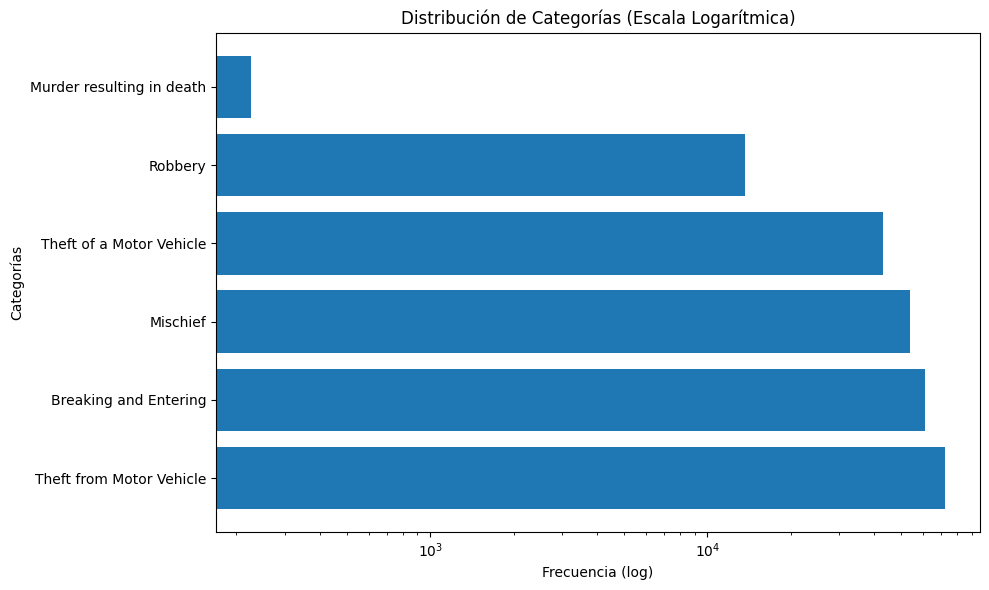

In [15]:
nuevas_etiquetas = Categorie_counts.index.map(categorie_significados)

plt.figure(figsize=(10,6))

plt.barh(
    y=nuevas_etiquetas,
    width=Categorie_counts.values
)

plt.xscale('log')

plt.title("Distribución de Categorías (Escala Logarítmica)")
plt.xlabel("Frecuencia (log)")
plt.ylabel("Categorías")

plt.tight_layout()

plt.show()

### A que horario del dia suceden la mayoria de incidentes?

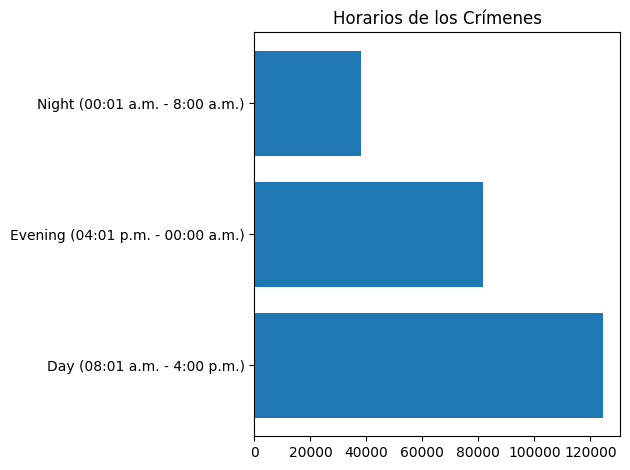

In [16]:
nuevas_etiquetas = []
for cat in Quart_counts.index:
    if cat in quart_significados:
        moment = quart_significados[cat]["Moment"]
        time = quart_significados[cat]["Time"]
        # Formateamos el texto final para la etiqueta
        nuevas_etiquetas.append(f'{moment} ({time})')
    else:
        # Por seguridad, si una categoría no está en el diccionario, dejamos su nombre original
        nuevas_etiquetas.append(cat)

# plt.pie(x = Quart_counts.values, labels = nuevas_etiquetas, autopct='%1.1f%%')

plt.barh(
    y=nuevas_etiquetas,
    width=Quart_counts.values
)
plt.title("Horarios de los Crímenes")
plt.tight_layout()
plt.show()

### Cual de los 5 departamentos de policia (PDQ) tienen la mayor denuncia de delitos?

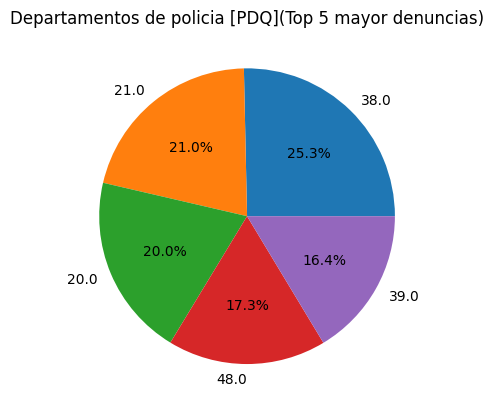

In [17]:
# nuevas_etiquetas = []
# for cat in Quart_counts.index:
#     if cat in quart_significados:
#         moment = quart_significados[cat]["Moment"]
#         time = quart_significados[cat]["Time"]
#         # Formateamos el texto final para la etiqueta
#         nuevas_etiquetas.append(f'{moment} ({time})')
#     else:
#         # Por seguridad, si una categoría no está en el diccionario, dejamos su nombre original
#         nuevas_etiquetas.append(cat)

# nuevaEtiqueta = pdq_counts.index.map(pdq_significados)

# pdq_counts.head(5)


plt.pie(x = pdq_counts.head(5).values, labels = pdq_counts.head(5).index, autopct='%1.1f%%')
plt.title("Departamentos de policia [PDQ](Top 5 mayor denuncias)")
plt.show()

### Cuales son los primeros 3 PDQs que tienen la menor denuncia de delitos?

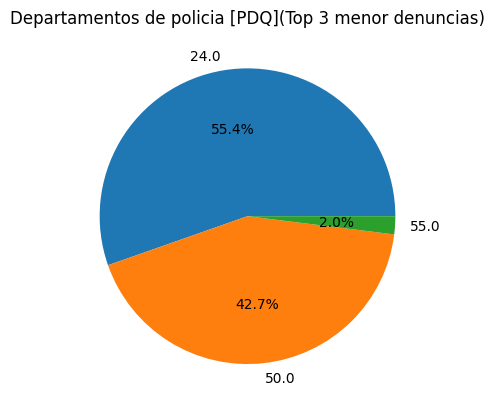

In [18]:
pdq_counts_min = df['PDQ'].value_counts().tail(3)


plt.pie(x = pdq_counts_min.values, labels = pdq_counts_min.index, autopct='%1.1f%%')
plt.title("Departamentos de policia [PDQ](Top 3 menor denuncias)")
plt.show()

### Que vecindario tiene el mayor registro de incidentes criminales y cuales son los tipos de crimenes en ese vecindario?

In [19]:
pdq_mayor = (
    df.groupby('PDQ')
    .size()
    .sort_values(ascending=False)
)

print(pdq_mayor.head(1))

PDQ
38.0    17265
dtype: int64


In [20]:
crimenes_pdq = (
    df[df['PDQ'] == pdq_mayor.index[0]]
    .groupby('CATEGORIE')
    .size()
    .sort_values(ascending=False)
)

print(crimenes_pdq)



CATEGORIE
Introduction                        6428
Vol dans / sur véhicule à moteur    4265
Méfait                              3923
Vol de véhicule à moteur            1728
Vols qualifiés                       908
Infractions entrainant la mort        13
dtype: int64


### Cual vecindario es el que tiene mayor casos de asesinato?

In [25]:
asesinatos_pdq = (
    df[
        df['CATEGORIE'] == 'Infractions entrainant la mort'
    ]
    .groupby('PDQ')
    .size()
)

pdq_max = asesinatos_pdq.idxmax()
max_asesinatos = asesinatos_pdq.max()

print('PDQ con más asesinatos:', pdq_max)
print('Cantidad de asesinatos:', max_asesinatos)

PDQ con más asesinatos: 39.0
Cantidad de asesinatos: 15


# Extra
## Mapa de calor de criminalidad

In [22]:
df_conteos = df[['LATITUDE', 'LONGITUDE', 'CATEGORIE','PDQ']].value_counts().reset_index(name='CONTEO')
df_conteos['CATEGORIE'] = (
    df_conteos['CATEGORIE']
    .replace(categorie_significados)
    .astype(str)
    .str.encode('utf-8', errors='ignore')
    .str.decode('utf-8')
)

df_conteos

,LATITUDE,LONGITUDE,CATEGORIE,PDQ,CONTEO
0,45.503177,-73.569807,Mischief,20.0,282
1,45.462563,-73.829217,Theft of a Motor Vehicle,5.0,255
2,45.500205,-73.585673,Theft from Motor Vehicle,20.0,235
3,45.480716,-73.698049,Theft of a Motor Vehicle,7.0,219
4,45.486555,-73.690203,Theft of a Motor Vehicle,7.0,190
...,...,...,...,...,...
55741,45.471990,-73.620071,Breaking and Entering,9.0,1
55742,45.488879,-73.783822,Theft from Motor Vehicle,4.0,1
55743,45.457926,-73.645998,Mischief,9.0,1
55744,45.491770,-73.563368,Mischief,15.0,1


In [23]:
import webbrowser

def mostrar_mapa(mapa, nombre="mapa.html"):
    mapa.save(nombre)
    webbrowser.open(nombre)

In [24]:
df_sectores = gpd.read_file('./Data/limitespdq.geojson')

df_sectores['PDQ'] = df_sectores['PDQ'].astype(float)

datos_calor = df_conteos[['LATITUDE', 'LONGITUDE', 'CONTEO']].values.tolist()

centro_lat = df_conteos['LATITUDE'].mean()
centro_lon = df_conteos['LONGITUDE'].mean()

mapa = folium.Map(
    location=[centro_lat, centro_lon],
    zoom_start=12,
    tiles="OpenStreetMap"
)
HeatMap(
    data = datos_calor, 
    radius=18, 
    blur=13, 
    min_opacity=0.4
).add_to(mapa)

def estilo_invisible(feature):
    return {
        'fillColor': '#ffffff',
        'color': '#333333',       # Bordes gris oscuro para delimitar las zonas
        'weight': 1,              # Línea delgada
        'fillOpacity': 0.1        # Casi transparente para que no tape el mapa de calor
    }

def estilo_resaltado(feature):
    return {
        'color': '#000000',       # El borde del cuadrante se vuelve negro al pasar el mouse
        'weight': 3,              # Línea más gruesa
        'fillOpacity': 0.25       # Se oscurece ligeramente para notar qué zona seleccionas
    }

df_sectores['PDQ'] = df_sectores['PDQ'].astype(str)
df_conteos['PDQ'] = df_conteos['PDQ'].astype(str)

# Sumar conteos por crimen dentro de cada PDQ
resumen_crimenes = (
    df_conteos
    .groupby(['PDQ', 'CATEGORIE'])['CONTEO']
    .sum()
    .reset_index()
    .sort_values(['PDQ', 'CONTEO'], ascending=[True, False])
)

# (Opcional) Top 5 delitos por PDQ
top_crimenes = (
    resumen_crimenes
    .groupby('PDQ')
    # .head(5)
)

# Crear texto HTML
crimenes_pdq = (
    top_crimenes
    # .groupby('PDQ')
    .apply(
        lambda x: "<br>".join(
            [
                f"{cat}: {cnt}"
                for cat, cnt in zip(x['CATEGORIE'], x['CONTEO'])
            ]
        )
    )
    .reset_index(name='CRIMENES')
)
df_sectores = df_sectores.merge(
    crimenes_pdq,
    on='PDQ',
    how='left'
)


tooltip = folium.GeoJsonTooltip(
    fields=['NOM_PDQ', 'PDQ', 'CRIMENES'],
    aliases=[
        'Sector Policial:',
        'ID Cuadrante:',
        'Crímenes Registrados:'
    ],
    localize=True,
    sticky=True,
    labels=True,
    parse_html=True,
    style="""
        background-color: #ffffff;
        border: 1px solid #333333;
        border-radius: 4px;
        font-family: sans-serif;
        padding: 8px;
        box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
    """
)

folium.GeoJson(
    df_sectores,
    style_function = estilo_invisible,
    highlight_function = estilo_resaltado,
    tooltip=tooltip
).add_to(mapa)

from branca.element import Template, MacroElement

template = """
{% macro html(this, kwargs) %}

<div style="
    position: fixed; 
    bottom: 40px;
    left: 40px;
    width: 220px;
    background-color: white;
    border:2px solid grey;
    z-index:9999;
    font-size:14px;
    padding: 10px;
    border-radius: 8px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
">

<b>Intensidad de Incidentes</b><br><br>

<div style="display:flex; align-items:center; margin-bottom:5px;">
    <div style="width:20px;height:20px;background:blue;margin-right:10px;"></div>
    Baja
</div>

<div style="display:flex; align-items:center; margin-bottom:5px;">
    <div style="width:20px;height:20px;background:lime;margin-right:10px;"></div>
    Media
</div>

<div style="display:flex; align-items:center; margin-bottom:5px;">
    <div style="width:20px;height:20px;background:yellow;margin-right:10px;"></div>
    Alta
</div>

<div style="display:flex; align-items:center;">
    <div style="width:20px;height:20px;background:red;margin-right:10px;"></div>
    Muy Alta
</div>

</div>

{% endmacro %}
"""

macro = MacroElement()
macro._template = Template(template)

mapa.get_root().add_child(macro)

# mapa.get_root().html.add_child(folium.Element(legend_html))

mapa.fit_bounds(mapa.get_bounds())

mostrar_mapa(mapa, "mapa_crimenes.html")